In [2]:
import ibis
from utils.f_0_dirs import get_data_dirs

dirs = get_data_dirs("descriptives")
con = ibis.duckdb.connect(str(dirs.db_path))

In [13]:
from ibis import _, selectors as s
import pandas as pd

table_name = "working_yearly"
old_table_name = "fame_yearly_kp"

t_panel = con.table(table_name)
t_old = (
    con.table(old_table_name)
    .select("registered_number", "year", "tangibles")
)

t_filtered = (
    t_panel
    .left_join(t_old, ["registered_number", "year"])
    .filter(
        (_.gva1 > 0) &
        (_.total_assets > 0) &
        (_.fixed_total > 0) &
        (_.tangibles > 0)
    )
)
df_stats_wide = (
    t_filtered
    .mutate(
        total_y=_.total_assets / _.gva1,
        fixed_y=_.fixed_total / _.gva1,
        tangibles_y=_.tangibles / _.gva1
    )
    .select('total_y', 'fixed_y', 'tangibles_y')
    .aggregate(
        s.across(s.all(), { "mean": _.mean(), "std": _.std() })
    )
    .execute()
)

s_flat = df_stats_wide.iloc[0]
s_flat.index = pd.MultiIndex.from_tuples(
    [col.rsplit("_", 1) for col in s_flat.index], 
    names=["column", "stat"]
)
df_stats = s_flat.unstack(level="stat")[["mean", "std"]]
# Add a row for the number of observations
df_stats.loc["n_obs", "mean"] = t_filtered.count().execute()
display(df_stats)

stat,mean,std
column,,
fixed_y,5.995464,1399.493418
tangibles_y,3.534172,1309.000736
total_y,11.563473,1810.382383
n_obs,991367.000000,NaN


In [ ]:
%%script true
from ibis import _, selectors as s
import pandas as pd

# 1. Execute the native Ibis aggregation (returns a single wide row)
t_panel = con.table("working_yearly_with_tfp_wave")
nb_rows = t_panel.count().execute()
raw_result = (
    t_panel
    .select(
        'tfp',
        'peer_tfp_ttwa_donut', 'peer_tfp_pc4_donut', 'peer_tfp_pc8',
        'tfp_wav1', 'tfp_wav2', 'tfp_wav3', 'nb_peers'
    )
    .aggregate(
        s.across(
            s.all(),
            {
                "count": _.count(),
                "percent": _.count() / nb_rows,
                "mean": _.mean(),
                "median": _.median(),
                "min": _.min(),
                "max": _.max(),
                "std": _.std(),
            }
        )
    )
    .execute()
)

# 2. Reshape the single row into a MultiIndex Series, then unstack
s_flat = raw_result.iloc[0]
s_flat.index = pd.MultiIndex.from_tuples(
    [col.rsplit("_", 1) for col in s_flat.index], 
    names=["variable", "metric"]
)

# 3. Pivot the metrics into separate columns
df_count = (
    s_flat
    .unstack(level="metric")[["count", "percent", "mean", "median", "min", "max", "std"]]
)

display(df_count.style.format({
    "count": "{:,.0f}",
    "percent": "{:.1%}",
    "mean": "{:,.3f}",
    "median": "{:,.3f}",
    "min": "{:,.3f}",
    "max": "{:,.3f}",
    "std": "{:,.3f}"
}))

Couldn't find program: 'true'


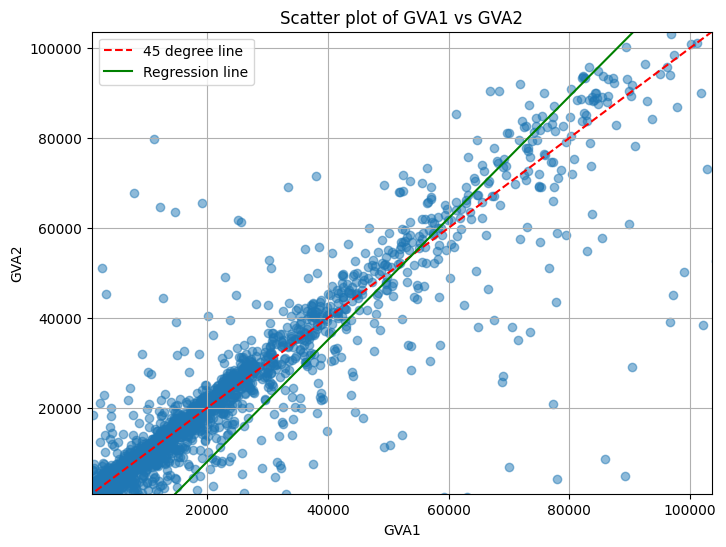

OLS Regression Results:
                            OLS Regression Results                            
Dep. Variable:                   gva2   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 6.744e+07
Date:                Wed, 26 Aug 2026   Prob (F-statistic):               0.00
Time:                        17:46:40   Log-Likelihood:            -8.3238e+06
No. Observations:              591538   AIC:                         1.665e+07
Df Residuals:                  591536   BIC:                         1.665e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.903e+04    406

In [ ]:
# Show a scatter plot of gva1 vs gva2
from ibis import _
import matplotlib.pyplot as plt
import statsmodels.api as sm

table_name = "working_yearly"
t_panel = con.table(table_name)
t_clean = (
    t_panel
    .select("gva1", "gva2")
    .drop_null()
    .filter((_.gva1 > 0) & (_.gva2 > 0))
    # Filter out 1% and 99% values
    .filter(
        (_.gva2.between(_.gva2.quantile(0.025), _.gva2.quantile(0.975))) &
        (_.gva1.between(_.gva1.quantile(0.025), _.gva1.quantile(0.975)))
    )
)

# OLS model of gva2 on gva1
df_clean = t_clean.execute()
X = df_clean["gva1"]
X = sm.add_constant(X)  # add constant term for intercept
y = df_clean["gva2"]
model = sm.OLS(y, X).fit()
df_clean["gva_2_pred"] = model.predict(X)
df_sample = (
    df_clean
    .sample(frac=0.01, random_state=1)
    .sort_values(by="gva1")
)

# Plot sample of gva1 vs gva2 with 45 degree line
plt.figure(figsize=(8, 6))
plt.scatter(df_sample["gva1"], df_sample["gva2"], alpha=0.5)
plt.xlabel("GVA1")
plt.ylabel("GVA2")
plt.title("Scatter plot of GVA1 vs GVA2")
plt.plot([df_sample["gva1"].min(), df_sample["gva1"].max()],
         [df_sample["gva1"].min(), df_sample["gva1"].max()], color='red', linestyle='--', label='45 degree line')
plt.plot(df_sample["gva1"], df_sample["gva_2_pred"], color='green', label='Regression line')
plt.legend()
value_min = min(df_clean["gva1"].quantile(0.05), df_clean["gva2"].quantile(0.05))
value_max = max(df_clean["gva1"].quantile(0.95), df_clean["gva2"].quantile(0.95))
plt.xlim(value_min, value_max)
plt.ylim(value_min, value_max)
plt.grid(True)
plt.show()

print("OLS Regression Results:")
print(model.summary())

### Summary statistics: number of years in panel available

In [ ]:
import ibis
from ibis import _, selectors as s
import pandas as pd
from utils.f_0_dirs import get_data_dirs

fixed_name = "working_fixed"
panel_name = "working_yearly"

dirs = get_data_dirs("descriptives")
con = ibis.duckdb.connect(str(dirs.db_path))
t_fixed = con.table(fixed_name)
t_panel = con.table(panel_name)

t_panel_valid = (
    t_panel
    .select("registered_number", "year", "tfp")
    .filter((_.tfp > 0))
    .group_by("registered_number")
    .aggregate(years_count=_.count())
)
t_fixed_valid = (
    t_fixed
    .select("registered_number", "pc8", "pc4", "ttwa")
    .drop_null()
    .inner_join(t_panel_valid, "registered_number")
    .filter((_.years_count > 0))
)

t_years_aggregated = (
    t_panel
    .group_by("year")
    .aggregate(number_of_rows=_.count())
    .filter(_.number_of_rows > 0)
    .order_by("year")
)

# df_stats_wide = (
#     t_fixed_valid
#     .aggregate(
#         s.across(["gva1"], {
#             "max": _.max(),
#             "min": _.min(),
#             "median": _.median(),
#             "mean": _.mean(),
#             "std": _.std()
#         })
#     )
#     .execute()
# )

# # 3. Reshape and format for clean display
# s_flat = df_stats_wide.iloc[0]
# s_flat.index = pd.MultiIndex.from_tuples(
#     [col.rsplit("_", 1) for col in s_flat.index], 
#     names=["column", "stat"]
# )
# df_stats = s_flat.unstack(level="stat")[["max", "min", "median", "mean", "std"]]

# # Add a row for the total number of firms observed
# df_stats.loc["n_obs", "mean"] = t_fixed_valid.count().execute()
# display(df_stats)

AttributeError: 'StringColumn' object has no attribute 'mean'

In [1]:
import ibis.selectors as s
from ibis import _
import pandas as pd

# 1. Group strictly by firm to count the number of valid years
t_filtered = (
    t_panel
    .distinct(on=["registered_number", "year"])
    .select("registered_number", "year", "gva1", "fixed_total")
    .filter(
        (_.gva1 > 0) &
        (_.fixed_total > 0)
    )
    .group_by("registered_number")
    .aggregate(years_count=_.count())
)

# 2. Calculate the descriptive statistics of the 'years_count' column
df_stats_wide = (
    t_filtered
    .aggregate(
        s.across("years_count", {
            "max": _.max(),
            "min": _.min(),
            "median": _.median(),
            "mean": _.mean(),
            "std": _.std()
        })
    )
    .execute()
)

# 3. Reshape and format for clean display
s_flat = df_stats_wide.iloc[0]
s_flat.index = pd.MultiIndex.from_tuples(
    [col.rsplit("_", 1) for col in s_flat.index], 
    names=["column", "stat"]
)
df_stats = s_flat.unstack(level="stat")[["max", "min", "median", "mean", "std"]]

# Add a row for the total number of firms observed
df_stats.loc["n_obs", "mean"] = t_filtered.count().execute()
display(df_stats)

NameError: name 't_panel' is not defined